## Oxford Nanopore DNA sequencing of four bacterial strains

**Hands-on Bioinformatics Tutorial - BIP Workshop**

---

In this session we work with **Oxford Nanopore R10.4.1 DNA sequencing** data. Four bacterial
strains were prepared together, **barcoded**, and sequenced on a **single MinION flow cell**:

| Strain | What it is |
|---|---|
| *Lacticaseibacillus casei* | a lactic-acid bacterium (yoghurt / probiotics) |
| *Bacillus subtilis* | a soil bacterium that forms spores |
| *Escherichia coli* DH5&alpha; | the harmless **lab cloning strain** you grow on the bench |
| *Escherichia coli* O157 | a **pathogenic** *E. coli* - same species as DH5&alpha;, very different lifestyle |

Our job is to take the raw sequencer output and, step by step:

1. look at the raw **signal** (pod5) and the **basecalling** that turns it into DNA letters,
2. **demultiplex** - sort the mixed reads back into the four strains by their barcode,
3. **quality-control** the reads,
4. **map** each strain's reads to a reference genome, and
5. **compare** the four genomes - ending with a neat trick: reading the number of
   **ribosomal RNA (rrn) operons** straight off the sequencing depth.

> *To start this tutorial, do the following steps (once):*
>
> This training can be downloaded at https://github.com/toddblev/bacto-ont
> Your working directory will be where you saved the github repo.
>
> **1. Navigate to the tutorial directory**
> ```bash
> cd bacto-ont
> ```
> **2. Create the tutorial environment**
> ```bash
> conda env create -f environment.yml
> ```
> **3. Activate the environment**
> ```bash
> conda activate bip
> ```
> **4. Start Jupyter and open the tutorial**
> ```bash
> jupyter lab bacto_ont.ipynb
> ```

In [1]:
# Check that the conda environment is active and the tools are available
! python --version
! samtools --version | head -1
! minimap2 --version
! NanoPlot --version
! fastplong --version 2>&1 | head -1
! mosdepth --version

Python 3.13.14


samtools 1.23


2.31-r1302


NanoPlot 1.47.1


fastplong 0.4.1


mosdepth 0.3.13


In [2]:
# ================================================================
#  DOWNLOAD the large data files that are too big for GitHub
# ----------------------------------------------------------------
#  Re-running this cell is safe: a file already on disk is skipped.
# ================================================================
import os, hashlib, urllib.request

DATA = {
    # destination path (relative to repo root): {url, md5}
    "pod5/bacto_subsample.pod5": {
        "url": "PASTE_DROPBOX_LINK?dl=1",
        "md5": "6749615cfcd99fd8eb4281c4cdb724d6",
    },
    "reads/barcode01.fastq": {"url": "PASTE_DROPBOX_LINK?dl=1", "md5": "6e2463ae7f51571cdcb3b478c8e1f290"},
    "reads/barcode02.fastq": {"url": "PASTE_DROPBOX_LINK?dl=1", "md5": "5c80665de406f4e96a2ed0af2e82b627"},
    "reads/barcode03.fastq": {"url": "PASTE_DROPBOX_LINK?dl=1", "md5": "c574bad1637bcb1b1ca06f447aa0f59a"},
    "reads/barcode04.fastq": {"url": "PASTE_DROPBOX_LINK?dl=1", "md5": "879e1c80b71eb030026ff70c053a37ce"},
}

def _md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def download(dest, url, md5=""):
    if os.path.exists(dest) and (not md5 or _md5(dest) == md5):
        print(f"✓ already present: {dest}")
        return
    if not url or url.startswith("PASTE_"):
        print(f"⚠ no URL set for {dest} (already on disk if you cloned with data)")
        return
    os.makedirs(os.path.dirname(dest) or ".", exist_ok=True)
    print(f"↓ downloading {dest} ...")
    urllib.request.urlretrieve(url, dest)
    print(f"✓ done: {dest} ({os.path.getsize(dest)/1e6:.0f} MB)")

for dest, meta in DATA.items():
    download(dest, meta["url"], meta.get("md5", ""))

✓ already present: pod5/bacto_subsample.pod5
✓ already present: reads/barcode01.fastq
✓ already present: reads/barcode02.fastq
✓ already present: reads/barcode03.fastq
✓ already present: reads/barcode04.fastq


### The experiment in one file: `samples.tsv`

Everything about the four samples is recorded in a small, human-readable table,
`samples.tsv`: which **barcode** each strain got, the **reference genome** we will map it to,
a single extracted **rrn operon** (used right at the end), and the known number of **rrn
operons** in each genome (the "answer" we will try to recover from the data).

> The barcode &rarr; strain assignment was worked out by mapping (you will reproduce it
> below). It is filled in here so the rest of the notebook can refer to strains by name.

In [3]:
import pandas as pd
samples = pd.read_csv("samples.tsv", sep="\t")
samples

,barcode,key,strain,reference,operon,rrn_copies
0,barcode01,bsubtilis,Bacillus subtilis 168,reference_seqs/ref_bsubtilis_168.fna,reference_seqs/operons/bsubtilis_rrn_operon.fna,10
1,barcode02,ecoli_O157,Escherichia coli O157:H7 Sakai,reference_seqs/ref_ecoli_O157_Sakai.fna,reference_seqs/operons/ecoli_O157_rrn_operon.fna,7
2,barcode03,lcasei,Lacticaseibacillus casei ATCC 393,reference_seqs/ref_lcasei_ATCC393.fna,reference_seqs/operons/lcasei_rrn_operon.fna,5
3,barcode04,ecoli_K12,Escherichia coli DH5alpha (K-12),reference_seqs/ref_ecoli_K12_MG1655.fna,reference_seqs/operons/ecoli_K12_rrn_operon.fna,7


### Tools for working with bioinformatics files

> Do **not** use Microsoft Word to view or edit sequence, mapping or annotation files
> (FASTA, FASTQ, GFF3, SAM...), tables (CSV/TSV) or scripts. Word alters plain text and can
> corrupt these files, and large files crash Word/Excel.

| Category | Recommendation | Notes |
|---|---|---|
| Editor | [VS Code](https://code.visualstudio.com/download) | best general-purpose choice for text-based bioinformatics files |
| Terminal | macOS [iTerm2](https://iterm2.com), Linux terminal, WSL, PowerShell | where you inspect files and run tools |
| Notebook | Jupyter | **this file** - great for exploring data and documenting analyses |

### Project directory layout

In [4]:
! tree -L 2 . 2>/dev/null || ls -F

.
├── analysis
│   ├── coverage_bsubtilis.png
│   ├── coverage_ecoli_K12.png
│   ├── coverage_track.py
│   ├── cross_mapping_matrix.png
│   ├── cross_mapping_matrix.py
│   ├── extract_rrn_operon.py
│   ├── gc_vs_size.png
│   ├── gc_vs_size.py
│   ├── rrn_copy_number.py
│   └── squiggle.png
├── bacto_ont.ipynb
├── basecalls
│   └── calls_demo.bam
├── cheatsheets
│   ├── conda_cheatsheet.pdf
│   ├── git_cheatsheet.pdf
│   ├── python_reference_pcc.pdf
│   ├── python_reference_rp.pdf
│   └── unix_linux_commands.pdf
├── environment.yml
├── fastplong.html
├── fastplong.json
├── LICENSE
├── mapping_bam
│   ├── bsubtilis.bam
│   ├── bsubtilis.bam.bai
│   ├── ecoli_K12.bam
│   ├── ecoli_K12.bam.bai
│   ├── ecoli_O157.bam
│   ├── ecoli_O157.bam.bai
│   ├── lcasei.bam
│   └── lcasei.bam.bai
├── pod5
│   └── bacto_subsample.pod5
├── _prep
│   ├── all_ids.txt
│   ├── basecall.log
│   ├── bc01_bsub.bam
│   ├── bc01_bsub.bam.bai
│   ├── bc01_bsub.mosdepth.global.dist.txt
│   ├── bc01_bsub.mosdepth.re

### Oxford Nanopore sequencing file formats

A Nanopore run moves through several file formats. The sequencer records the raw electrical
**signal** in **pod5** files - the current format for both **DNA (R10.4.1)** and RNA flow
cells, replacing the older **fast5**. **Basecalling** then turns that signal into reads, which
Dorado writes as **BAM** (here BAM stores the basecalled reads *before* any mapping, and can
also carry DNA **modification** calls). For most tools we convert reads to **FASTQ**. The run
also emits plain-**text** summaries/logs.

| Format | Role |
|---|---|
| `pod5` | raw-signal format for DNA (R10.4.1) and RNA flow cells |
| `fast5` | legacy raw-signal format (older R9.4.1 chemistry) - deprecated |
| `BAM` | basecalled reads (even before mapping); can include modification info; also the alignment format |
| `FASTQ` | standard read format (sequence + quality); cannot store modification info |
| `text` | summaries and logs (e.g. `sequencing_summary.txt`) |

### Inspecting the raw signal (pod5)

The full run is dozens of large pod5 files (many GB). For this tutorial we use a small random
**subsample**, `pod5/bacto_subsample.pod5` (25,000 reads). pod5 files are **binary** - they
cannot be opened in a text editor; we use the `pod5` tool to look inside.

In [5]:
! pod5 inspect summary pod5/bacto_subsample.pod5 | head

Originating file version 0.3.39, in memory read table version 4.
File version on disk 0.3.39.
File uses VBZ compression.
Batch 1, 1000 reads
Batch 2, 1000 reads
Batch 3, 1000 reads
Batch 4, 1000 reads
Batch 5, 1000 reads
Batch 6, 1000 reads
Batch 7, 1000 reads


In [6]:
# the per-read metadata table (channel = pore, num_samples = signal length, sample_rate = Hz)
! pod5 view pod5/bacto_subsample.pod5 | head

read_id	filename	read_number	channel	mux	end_reason	start_time	start_sample	duration	num_samples	minknow_events	sample_rate	median_before	predicted_scaling_scale	predicted_scaling_shift	tracked_scaling_scale	tracked_scaling_shift	num_reads_since_mux_change	time_since_mux_change	run_id	sample_id	experiment_id	flow_cell_id	pore_type	open_pore_level


8bdf8241-03b2-4668-a2ea-2d7b16392d92	bacto_subsample.pod5	9	390	4	signal_positive	2724.26680000	13621334	9.92580000	49629	5832	5000	190.32186890	0.00000000	0.00000000	0.00000000	0.00000000	0	0.00000000	e9e97897-3865-4a54-8f92-5c4515fc39c7	not_set	093_BIP_rapid_test	FAW56562	not_set	NaN
6d344c52-bd46-4669-9eba-6fe4166200ae	bacto_subsample.pod5	86	402	4	signal_positive	2722.94180000	13614709	23.57320000	117866	12891	5000	196.85742188	0.00000000	0.00000000	0.00000000	0.00000000	0	0.00000000	e9e97897-3865-4a54-8f92-5c4515fc39c7	not_set	093_BIP_rapid_test	FAW56562	not_set	NaN
6a93c5f4-7d91-45de-850f-e23fb8d75486	bacto_subsample.pod5	118	414	4	unblock_mux_change	2743.02060000	13715103	9.11640000	45582	5285	5000	193.90826416	0.00000000	0.00000000	0.00000000	0.00000000	0	0.00000000	e9e97897-3865-4a54-8f92-5c4515fc39c7	not_set	093_BIP_rapid_test	FAW56562	not_set	NaN
12f6c634-3ca0-4d72-86a9-a25696bffd31	bacto_subsample.pod5	219	299	4	signal_positive	2748.14960000	13740748	31.69300000	158465	1884

In [7]:
# Open the file in Python, take the first read, and print info from the raw data.
# Note: R10.4.1 DNA runs sample at 5 kHz and translocate DNA at ~400 bases/second.
import pod5

with pod5.Reader("pod5/bacto_subsample.pod5") as reader:
    read = next(reader.reads())
    sr = read.run_info.sample_rate
    print("read_id      :", read.read_id)
    print("flow cell    :", read.run_info.flow_cell_id)
    print("pore channel :", read.pore.channel)
    print("sample rate  :", sr, "Hz")
    print("num samples  :", read.num_samples, "signal points")
    print("duration     :", round(read.num_samples / sr, 3), "seconds")
    print("raw signal   :", read.signal[:10], "...")

read_id      : 8bdf8241-03b2-4668-a2ea-2d7b16392d92
flow cell    : FAW56562
pore channel : 390
sample rate  : 5000 Hz
num samples  : 49629 signal points
duration     : 9.926 seconds
raw signal   : [466 475 509 471 484 505 513 522 496 515] ...


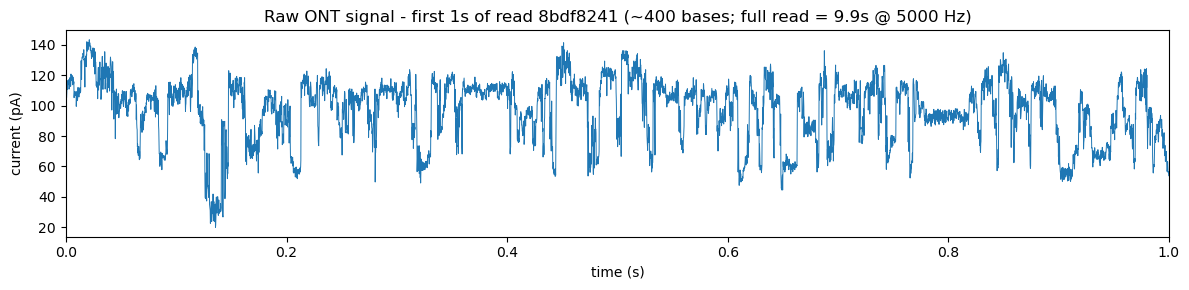

In [8]:
# Plot one read's raw signal - the ONT "squiggle". The basecaller's job is to read
# the DNA sequence out of wiggles like these.
# A full read is many seconds long; at ~400 bases/s and 5 kHz that is ~12 samples per base,
# so we zoom into a 1-second window (~400 bases) to actually see the signal stepping.
import matplotlib.pyplot as plt
import numpy as np
import pod5

WINDOW_S = 1.0
with pod5.Reader("pod5/bacto_subsample.pod5") as reader:
    read = next(reader.reads())
    current_pa = read.signal_pa            # calibrated current in picoamps
    sr = read.run_info.sample_rate
    rid = str(read.read_id)

n = int(WINDOW_S * sr)
s = current_pa[:n]
t = np.arange(len(s)) / sr
plt.figure(figsize=(12, 3))
plt.plot(t, s, lw=0.7)
plt.xlim(0, WINDOW_S)
plt.xlabel("time (s)"); plt.ylabel("current (pA)")
plt.title(f"Raw ONT signal - first {WINDOW_S:g}s of read {rid[:8]} "
          f"(~{int(WINDOW_S*400)} bases; full read = {len(current_pa)/sr:.1f}s @ {sr} Hz)")
plt.tight_layout(); plt.savefig("analysis/squiggle.png", dpi=130); plt.show()

### Basecalling: Dorado and its accuracy models

[Dorado](https://software-docs.nanoporetech.com/dorado/latest/) turns the raw signal into DNA
sequence. It offers three accuracy levels - **fast**, **hac** (high accuracy) and **sup**
(super accuracy) - trading speed for accuracy. Basecalling needs an NVIDIA GPU and takes a
while, so **we did it for you ahead of time**; this section just shows the results.

| Level | Model (R10.4.1 DNA) | Speed | Accuracy |
|---|---|---|---|
| fast | `dna_r10.4.1_e8.2_400bps_fast` | fastest | lowest |
| hac  | `dna_r10.4.1_e8.2_400bps_hac`  | medium  | high |
| sup  | `dna_r10.4.1_e8.2_400bps_sup`  | slowest | highest |

> *Note:* the latest model **version** differs per level on our system (fast/sup `@v5.2.0`,
> hac `@v6.0.0`); a strictly fair comparison would use one version, so read the numbers below
> as indicative.

We basecalled the same 20,000 reads with each model and compared them with **NanoComp**.

In [9]:
# Summary statistics for the three models (generated offline with NanoComp)
! sed -n '1,20p' qc/model_compare/models_NanoStats.txt

General summary:                   fast            hac            sup
Active channels:                  175.0          175.0          175.0
Mean read length:               2,167.9        2,198.0        2,211.5
Mean read quality:                  5.6            7.0            7.2
Median read length:               500.0          493.0          499.0
Median read quality:                6.2            8.3            8.7
Number of reads:               20,148.0       20,175.0       20,206.0
Read length N50:                8,292.0        8,507.0        8,601.0
STDEV read length:              4,457.2        4,542.3        4,557.7
Total bases:               43,679,408.0   44,344,176.0   44,684,585.0
Number, percentage and megabases of reads above quality cutoffs
>Q10:	1788 (8.9%) 5.6Mb	7887 (39.1%) 22.6Mb	8889 (44.0%) 24.3Mb
>Q15:	7 (0.0%) 0.0Mb	3349 (16.6%) 12.4Mb	5271 (26.1%) 17.2Mb
>Q20:	3 (0.0%) 0.0Mb	359 (1.8%) 0.7Mb	1861 (9.2%) 6.5Mb
>Q25:	1 (0.0%) 0.0Mb	21 (0.1%) 0.0Mb	273 (1.4%) 0.3Mb
>

In [10]:
# Interactive quality comparison (fast -> hac -> sup), rendered inline
from IPython.display import IFrame
IFrame("qc/model_compare/models_NanoComp_quals_violin.html", width="100%", height=600)

Quality improves **fast &rarr; hac &rarr; sup**, as expected. R10.4.1 DNA is high quality:
even hac is very good, and sup adds the extra accuracy that matters for fine analyses. For the
rest of the tutorial we use the **sup**-basecalled reads (provided).

### Demultiplexing: sorting the reads back into four strains

All four strains were sequenced **together** on one flow cell. During library prep each strain
got a short DNA **barcode** (kit **SQK-RBK114-24**, "Rapid Barcoding"). After basecalling, every
read carries the barcode it was read with, and **demultiplexing** uses that to sort reads into
per-strain files.

We ran the demultiplexing for you with Dorado:

```bash
# (instructor step, needs the dorado binary)
dorado demux --no-classify --emit-fastq --emit-summary -o demux_out calls.bam
```

Each basecalled read carries its barcode as a **BC** tag - you can see it in the BAM:

In [11]:
# one basecalled read; note the BC:Z:...barcodeNN tag added during basecalling
! samtools view basecalls/calls_demo.bam | grep -m1 "BC:Z:SQK" | tr '\t' '\n' | grep -E "^BC|^RG"

BC:Z:SQK-RBK114-24_barcode02
RG:Z:e9e97897-3865-4a54-8f92-5c4515fc39c7_dna_r10.4.1_e8.2_400bps_sup@v5.2.0_SQK-RBK114-24_barcode02
samtools view: writing to standard output failed: Broken pipe
samtools view: error reading file "basecalls/calls_demo.bam": Broken pipe
samtools view: error closing standard output: -1


Demultiplexing produced one FASTQ per barcode. How many reads landed in each? And how many
could **not** be assigned to any barcode (**unclassified**)?

barcode01: 12,543 reads
barcode02: 20,276 reads
barcode03: 14,251 reads
barcode04: 23,776 reads


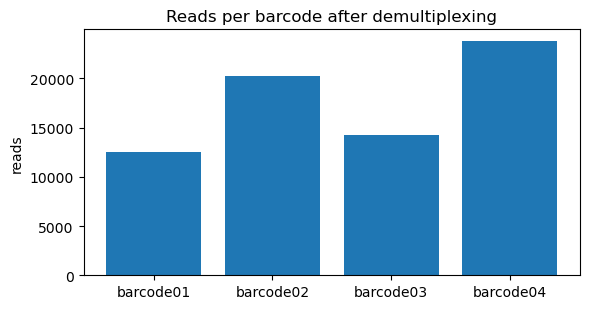

In [12]:
# count reads per barcode FASTQ (4 lines per read)
import glob, os, subprocess
import matplotlib.pyplot as plt

counts = {}
for fq in sorted(glob.glob("reads/barcode0[1-4].fastq")):
    n = int(subprocess.run(["wc","-l",fq], capture_output=True, text=True).stdout.split()[0]) // 4
    counts[os.path.basename(fq).replace(".fastq","")] = n
for bc, n in counts.items():
    print(f"{bc}: {n:,} reads")

plt.figure(figsize=(6,3.2))
plt.bar(counts.keys(), counts.values())
plt.ylabel("reads"); plt.title("Reads per barcode after demultiplexing")
plt.tight_layout(); plt.savefig("analysis/demux_read_counts.png", dpi=130); plt.show()

A large fraction of reads is typically **unclassified** with rapid barcoding (the barcode sits
on only one end and is easily missed on short or low-quality reads) - in this run about a third.
That is normal, and a good reminder that demultiplexing is never perfect. We continue with the
four well-populated barcodes.

In [13]:
# the reads are plain FASTQ - 4 lines per read (id / sequence / + / quality)
! head -n 4 reads/barcode01.fastq

@2e7f6508-a52e-4a9f-b0e4-5d1b7dcfa0c4	qs:f:11.5391	ch:i:30	st:Z:2026-06-09T18:21:23.013000+00:00	RG:Z:e9e97897-3865-4a54-8f92-5c4515fc39c7_dna_r10.4.1_e8.2_400bps_sup@v5.2.0_SQK-RBK114-24_barcode01	PU:Z:FAW56562	DT:Z:2026-06-09T15:20:19.095000+00:00	SM:Z:unclassified	al:Z:barcode01	tm:Z:adapter,primer,barcode
CAAGCACATCTGAACAATACATGAAAGATGAACTGCTGATCGAAAAGTCTCTGATTC
+
DOSSSMMHE::9@@C:88+)((((()&''''(*+>??==<==CBBG<8==::82--#


### Phred quality scores

Each base in a FASTQ has a **Phred quality score** `Q` estimating the probability `P` that the
base call is **wrong**:

$$Q = -10\cdot\log_{10}(P) \qquad\Longleftrightarrow\qquad P = 10^{-Q/10}$$

So Q10 &asymp; 90% correct, Q20 &asymp; 99%, Q30 &asymp; 99.9%. In the FASTQ, line 4 stores one
**ASCII character** per base (**Phred+33** encoding):

```
  ASCII:  !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRS
          |         |         |         |         |         |
  Q:      0         10        20        30        40        50
```

Dorado's neural network emits a confidence for every base; that becomes the Q score written next
to it. The model comparison above summarised exactly these per-base scores.

### Quality-control pipeline

Before mapping we clean the reads. Three standard steps:

```
   raw reads --> [1] NanoPlot (look)  -->  [2] fastplong (filter)  -->  [3] NanoComp (before vs after)
```

NanoPlot summarises the raw reads, **fastplong** filters them, and NanoComp shows the effect.
We demonstrate on one strain; the same recipe applies to all four.

#### QC1 - NanoPlot: look at the raw reads

In [14]:
! NanoPlot --fastq reads/barcode04.fastq -o qc/bc04_raw --prefix bc04_raw_ --loglength -t 4 2>/dev/null
! ls qc/bc04_raw/*.png | head

ls: cannot access 'qc/bc04_raw/*.png': No such file or directory


In [15]:
from IPython.display import IFrame
IFrame("qc/bc04_raw/bc04_raw_LengthvsQualityScatterPlot_loglength_kde.html", width="100%", height=600)

#### QC2 - fastplong: filter the reads

This is a **rapid-barcoding** run, which produces a wide spread of read lengths including many
**short** reads. We apply a *gentle* clean-up - drop obvious junk, keep the useful reads:

- `-l 500` drop short fragments (< 500 bp) that map poorly; keep everything longer. No upper limit.
- `-m 10` a light quality floor (mean Phred Q &ge; 10). Few reads fail it - the short reads in this
  run are not especially low quality - so for this run **length** is the dominant filter.
- `-A` disable adapter trimming - Dorado already removed the sequencing adapter and barcode.

In [16]:
# Filter all four barcodes with fastplong (loop over samples.tsv)
import pandas as pd, subprocess, os
samples = pd.read_csv("samples.tsv", sep="\t")
os.makedirs("qc", exist_ok=True)
for _, r in samples.iterrows():
    raw = f"reads/{r['barcode']}.fastq"
    clean = f"reads/{r['barcode']}.clean.fastq"
    subprocess.run(["fastplong","-i",raw,"-o",clean,"-l","1000","-m","12","-A",
                    "-w","8","--html",f"qc/{r['barcode']}.fastplong.html",
                    "--json",f"qc/{r['barcode']}.fastplong.json"],
                   capture_output=True)
    raw_n  = int(subprocess.run(["wc","-l",raw],  capture_output=True, text=True).stdout.split()[0])//4
    cln_n  = int(subprocess.run(["wc","-l",clean],capture_output=True, text=True).stdout.split()[0])//4
    print(f"{r['strain']:35s} {raw_n:>7,} -> {cln_n:>7,} reads kept ({100*cln_n/raw_n:.0f}%)")

Bacillus subtilis 168                12,543 ->   3,088 reads kept (25%)


Escherichia coli O157:H7 Sakai       20,276 ->   5,593 reads kept (28%)


Lacticaseibacillus casei ATCC 393    14,251 ->   1,924 reads kept (14%)


Escherichia coli DH5alpha (K-12)     23,776 ->   9,946 reads kept (42%)


#### QC3 - NanoComp: compare before vs after (one strain)

In [17]:
! NanoComp --fastq reads/barcode04.fastq reads/barcode04.clean.fastq \
           --names raw clean -o qc/bc04_rawvsclean --prefix bc04_ -t 4 2>/dev/null
from IPython.display import IFrame
IFrame("qc/bc04_rawvsclean/bc04_NanoComp_quals_violin.html", width="100%", height=600)

### CATCH-UP checkpoint

If anything above did not run, download the cleaned per-strain reads here and continue.
(Re-running is safe; present files are skipped.)

In [18]:
CATCHUP = {
    "reads/barcode01.clean.fastq": {"url": "PASTE_DROPBOX_LINK?dl=1", "md5": "1f5d91cbb3b9ab90049c86368c7cb14d"},
    "reads/barcode02.clean.fastq": {"url": "PASTE_DROPBOX_LINK?dl=1", "md5": "e4628ea59fb1a8ec89baab39d6f18204"},
    "reads/barcode03.clean.fastq": {"url": "PASTE_DROPBOX_LINK?dl=1", "md5": "1a84b3c5f0751761df4aad527c80eee1"},
    "reads/barcode04.clean.fastq": {"url": "PASTE_DROPBOX_LINK?dl=1", "md5": "4e3b7293a49fbb9a79a66bc7c3c2e7c5"},
}
for dest, meta in CATCHUP.items():
    download(dest, meta["url"], meta.get("md5", ""))

✓ already present: reads/barcode01.clean.fastq
✓ already present: reads/barcode02.clean.fastq
✓ already present: reads/barcode03.clean.fastq
✓ already present: reads/barcode04.clean.fastq


### Reference genomes

To make sense of the reads we map them to **reference genomes** - finished sequences for each
species, downloaded from NCBI. Notice the **gradient of relatedness**, which is the heart of the
comparison:

| Strain | Genome size | GC% | rrn operons | relationship |
|---|--:|--:|--:|---|
| *L. casei* ATCC 393 | ~3.0 Mb | ~48% | 5 | different genus |
| *B. subtilis* 168 | ~4.2 Mb | ~44% | 10 | different genus |
| *E. coli* DH5&alpha; (K-12) | ~4.6 Mb | ~51% | 7 | lab strain |
| *E. coli* O157 (Sakai) | ~5.5 Mb | ~51% | 7 | **same species** as DH5&alpha;, pathogen |

We download each genome from NCBI with Biopython (Entrez). The *E. coli* O157 download includes
its two **plasmids** - extra DNA molecules separate from the chromosome (we return to these later).

In [19]:
# Download the reference genomes from NCBI (skips files already present)
import os
from Bio import Entrez, SeqIO
Entrez.email = "your.email@example.com"   # NCBI asks for an email

REFS = {
    "reference_seqs/ref_lcasei_ATCC393.fna":   "AP012544.1,AP012545.1,AP012546.1",
    "reference_seqs/ref_bsubtilis_168.fna":    "NC_000964.3",
    "reference_seqs/ref_ecoli_K12_MG1655.fna": "NC_000913.3",
    "reference_seqs/ref_ecoli_O157_Sakai.fna": "NC_002695.2,NC_002128.1,NC_002127.1",
}
os.makedirs("reference_seqs", exist_ok=True)
for path, acc in REFS.items():
    if os.path.exists(path):
        print(f"✓ {path}")
        continue
    with Entrez.efetch(db="nucleotide", id=acc, rettype="fasta", retmode="text") as h:
        open(path, "w").write(h.read())
    print(f"↓ {path}")

✓ reference_seqs/ref_lcasei_ATCC393.fna
✓ reference_seqs/ref_bsubtilis_168.fna
✓ reference_seqs/ref_ecoli_K12_MG1655.fna
✓ reference_seqs/ref_ecoli_O157_Sakai.fna


In [20]:
# A FASTA can hold several sequences (chromosome + plasmids). Summarise one reference:
! python reference_seqs/read_fasta_bio.py reference_seqs/ref_ecoli_O157_Sakai.fna

NC_002695.2, length 5498578 nt
NC_002128.1, length 92721 nt
NC_002127.1, length 3306 nt
---------------------------
Total length parsed: 5594605 nt


### Mapping reads with minimap2

[minimap2](https://github.com/lh3/minimap2) is the standard aligner for long, error-prone ONT
reads. For each read it finds where it best fits on a reference and writes the alignment in
**SAM/BAM**. We use the `-ax map-ont` preset (tuned for ONT), `--secondary=no` (keep one best
location per read), then `samtools sort` + `index`.

Two different things are called an *index*: the **reference index** minimap2 builds to place
reads, and the **BAM index** (`.bai`) `samtools` builds so tools can jump to a region of a sorted
BAM. We always **sort then index**.

In [21]:
! minimap2 --help 2>&1 | head -5

Usage: minimap2 [options] <target.fa>|<target.idx> [query.fa] [...]
Options:
  Indexing:
    -H           use homopolymer-compressed k-mer (preferrable for PacBio)
    -k INT       k-mer size (no larger than 28) [15]


### First comparison: genome size and GC%

Two simple numbers already separate most of the strains. **Genome size** gives a clean ladder,
and **GC%** separates the high-GC *E. coli* from the lower-GC Firmicutes. But the two *E. coli*
land almost on top of each other - size and base composition **cannot** tell them apart. That is
exactly why we need to look at the reads.

Bacillus subtilis 168                4.22 Mb   GC 43.5%   rrn 10


Escherichia coli O157:H7 Sakai       5.59 Mb   GC 50.5%   rrn 7
Lacticaseibacillus casei ATCC 393    2.95 Mb   GC 47.9%   rrn 5


Escherichia coli DH5alpha (K-12)     4.64 Mb   GC 50.8%   rrn 7


-> analysis/gc_vs_size.png


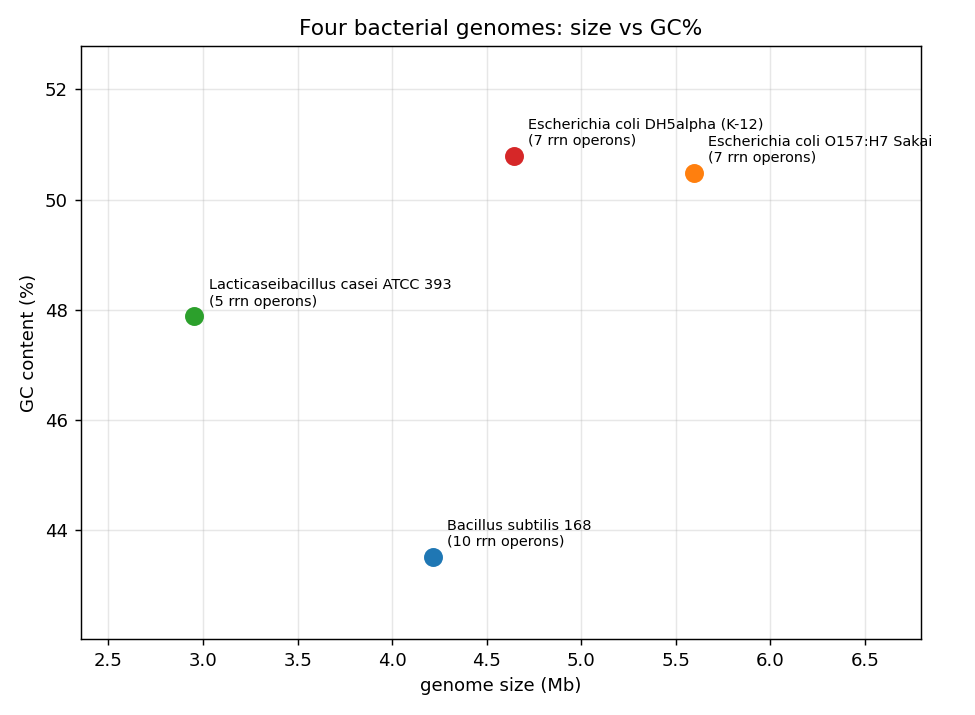

In [22]:
! python analysis/gc_vs_size.py
from IPython.display import Image
Image("analysis/gc_vs_size.png")

### Map each strain to its genome

Now map each strain's cleaned reads to its reference, and check how well they map and how deep
the coverage is.

In [23]:
import pandas as pd, subprocess, os
samples = pd.read_csv("samples.tsv", sep="\t")
os.makedirs("mapping_bam", exist_ok=True)
for _, r in samples.iterrows():
    clean = f"reads/{r['barcode']}.clean.fastq"
    bam = f"mapping_bam/{r['key']}.bam"
    mm = subprocess.Popen(["minimap2","-ax","map-ont","--secondary=no","-t","8",
                           r["reference"], clean], stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)
    subprocess.run(["samtools","sort","-o",bam,"-"], stdin=mm.stdout); mm.wait()
    subprocess.run(["samtools","index",bam])
    cov = subprocess.run(["samtools","coverage",bam], capture_output=True, text=True).stdout
    # mean depth of the longest contig (the chromosome)
    rows = [l.split("\t") for l in cov.strip().splitlines()[1:]]
    chrom = max(rows, key=lambda x: int(x[2]))
    print(f"{r['strain']:35s} chromosome mean depth ~{float(chrom[6]):.1f}x")

Bacillus subtilis 168               chromosome mean depth ~4.0x


Escherichia coli O157:H7 Sakai      chromosome mean depth ~6.6x


Lacticaseibacillus casei ATCC 393   chromosome mean depth ~1.9x


Escherichia coli DH5alpha (K-12)    chromosome mean depth ~14.4x


### Telling the strains apart: cross-mapping

If size and GC% cannot separate the two *E. coli*, can the reads? We map **every barcode against
every reference** and record the percentage that maps. The result is very informative:

- each barcode maps overwhelmingly to **one** genome (the bright diagonal) - that is how we
  assigned barcodes to strains;
- *L. casei* and *B. subtilis* map **only** to themselves (different genera);
- the two *E. coli* cross-map to **both** *E. coli* references - because they are the **same
  species**. "% mapped" alone cannot separate strains of one species;
- but look closely: **O157 reads map noticeably worse to DH5&alpha; than to O157**. That gap is
  O157's **extra DNA** (~0.9 Mb of prophage and other content) that simply has nowhere to map in
  the smaller DH5&alpha; genome.

mapping each barcode against each reference ...


  Bacillus subtilis 168               -> Bacillus subtilis 168   (79.6   0.6   1.0   0.6)


  Escherichia coli O157:H7 Sakai      -> Escherichia coli O157:H7 Sakai   ( 0.5  78.9   0.4  62.0)


  Lacticaseibacillus casei ATCC 393   -> Lacticaseibacillus casei ATCC 393   ( 0.6   0.3  76.9   0.3)


  Escherichia coli DH5alpha (K-12)    -> Escherichia coli DH5alpha (K-12)   ( 1.2  78.8   1.0  81.9)


-> analysis/cross_mapping_matrix.png


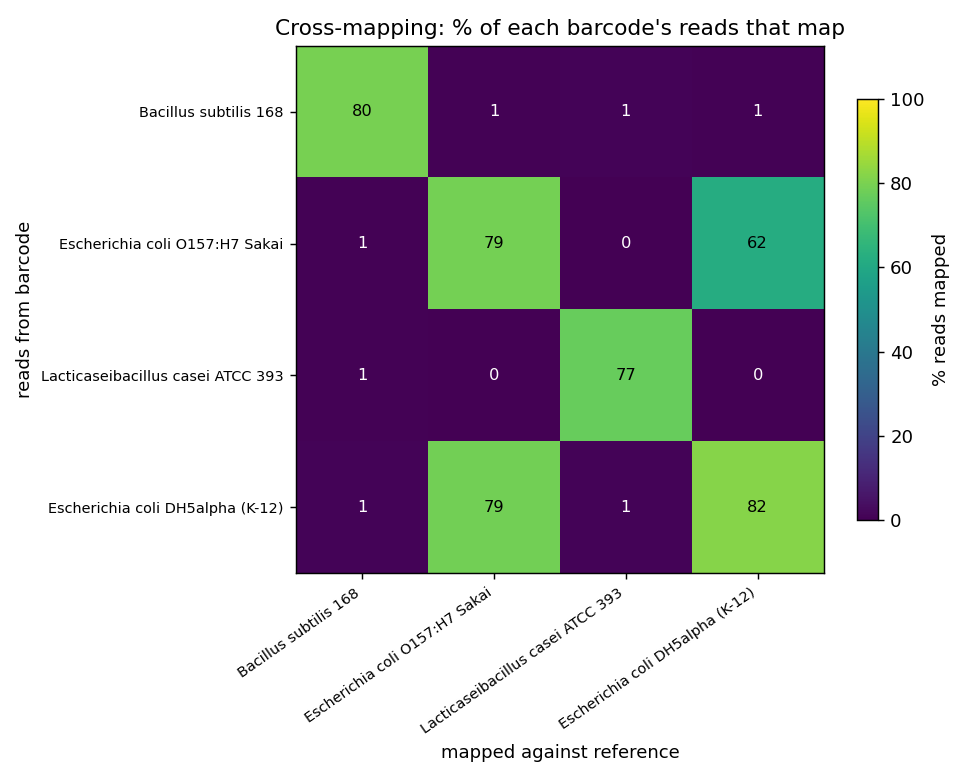

In [24]:
! python analysis/cross_mapping_matrix.py --reads-dir reads
from IPython.display import Image
Image("analysis/cross_mapping_matrix.png")

### One read, several alignment lines (and MAPQ)

A read can produce more than one line in a BAM. The SAM **FLAG** distinguishes them:

| Kind | FLAG bit | Meaning |
|---|---|---|
| primary | - | the single best alignment of the read |
| secondary | `0x100` | an alternative full location (maps about equally well elsewhere) |
| supplementary | `0x800` | a chimeric/split alignment (different parts map to different places) |

To count **distinct reads** we drop secondary+supplementary with `-F 0x900`.

Each alignment also has a **MAPQ** (column 5): the confidence that the read is in the **right
place**. High MAPQ (max 60) = one clear location; MAPQ **0** = the read fits two or more places
equally well. This matters next: the **rrn operons are repeated** several times per genome and
are nearly identical, so reads inside them are ambiguous (MAPQ 0).

In [25]:
# distinct mapped reads (primary only) for one strain
! echo 'B. subtilis primary-mapped reads:'; samtools view -c -F 0x900 mapping_bam/bsubtilis.bam

B. subtilis primary-mapped reads:
3088


## The climax: rrn operon copy number from coverage depth

Bacteria carry several copies of the **ribosomal RNA (rrn) operon** (the 16S-23S-5S genes).
Fast-growing bacteria tend to have **more** copies. Our four strains have known counts:
*L. casei* **5**, *E. coli* **7**, *B. subtilis* **10**. Can we recover these from the reads?

**First idea (that does not work):** look for tall coverage spikes at the operons on the genome.
Let's try it.

NC_000913.3: 4642 windows, median depth 14.7x  ->  analysis/coverage_ecoli_K12.png


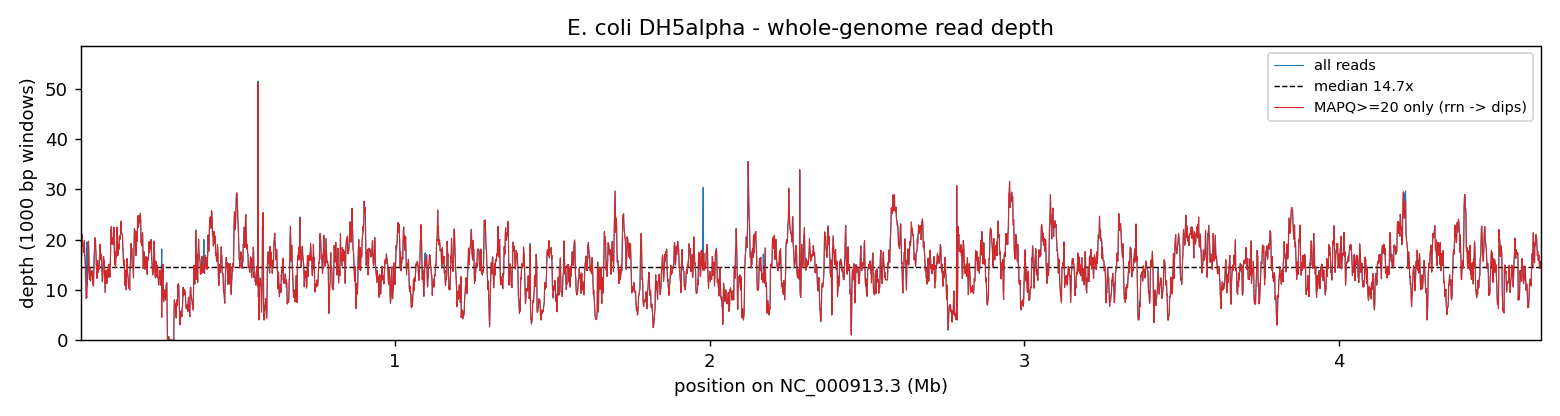

In [26]:
# Whole-genome coverage for E. coli DH5alpha (our deepest sample), with a MAPQ-filtered overlay
! python analysis/coverage_track.py mapping_bam/ecoli_K12.bam analysis/coverage_ecoli_K12.png \
        --title "E. coli DH5alpha - whole-genome read depth" --mapq 20
from IPython.display import Image
Image("analysis/coverage_ecoli_K12.png")

The coverage is **flat** - no towering peaks at the operons (you might have expected ~7-fold
spikes for the seven copies). Why? ONT reads are long enough to span an operon **plus** its unique
neighbouring genes, so most operon reads are placed at their **correct** copy, spreading evenly.
Reads that fall entirely inside the conserved core are ambiguous (MAPQ 0) and get scattered across
the copies. Look at the few thin **blue** spikes (e.g. near 0.55, 2.0, 4.2 Mb): the red
**MAPQ-filtered** track *drops* there, because those are the rrn operons and removing the ambiguous
reads empties them out. So copy number is **not** readable as spike height.

**The trick that works:** map the reads to **one single operon** instead of the whole genome.
Now reads from *all* the genomic copies have only one place to go, so they **pile up** to roughly
(copy number) &times; the normal single-copy depth:

$$\text{copy number} \;\approx\; \frac{\text{depth on one operon}}{\text{genome-median depth}}$$

== rrn operon copy number: Bacillus subtilis 168 ==
  genome-median depth (single copy) :   3.9x   (NC_000964.3)
  single-operon pile-up depth       :  29.8x   (operon 5001 bp)
  estimated copy number  = 29.8 / 3.9 = 7.6   (expected 10)



== rrn operon copy number: Escherichia coli O157:H7 Sakai ==
  genome-median depth (single copy) :   6.5x   (NC_002695.2)
  single-operon pile-up depth       :  26.0x   (operon 5095 bp)
  estimated copy number  = 26.0 / 6.5 = 4.0   (expected 7)



== rrn operon copy number: Lacticaseibacillus casei ATCC 393 ==
  genome-median depth (single copy) :   1.8x   (AP012544.1)
  single-operon pile-up depth       :   8.9x   (operon 5021 bp)
  estimated copy number  = 8.9 / 1.8 = 5.0   (expected 5)



== rrn operon copy number: Escherichia coli DH5alpha (K-12) ==
  genome-median depth (single copy) :  14.7x   (NC_000913.3)
  single-operon pile-up depth       : 120.3x   (operon 5105 bp)
  estimated copy number  = 120.3 / 14.7 = 8.2   (expected 7)



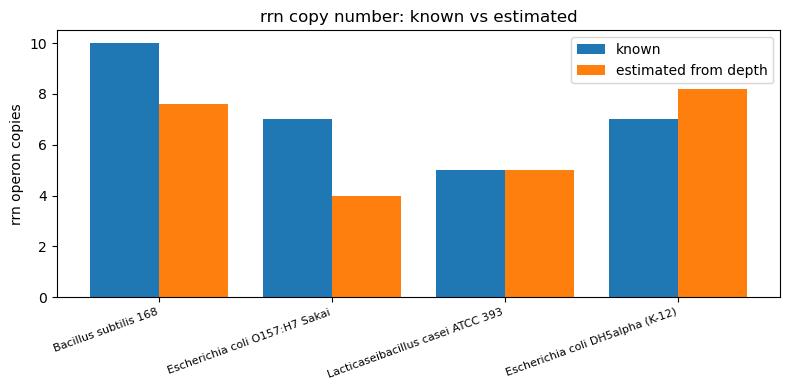

In [27]:
# Estimate rrn copy number for every strain (collapsed-reference method)
import pandas as pd, subprocess
samples = pd.read_csv("samples.tsv", sep="\t")
import matplotlib.pyplot as plt

est, exp, labs = [], [], []
for _, r in samples.iterrows():
    out = subprocess.run(["python","analysis/rrn_copy_number.py",
                          "--fastq", f"reads/{r['barcode']}.clean.fastq",
                          "--operon", r["operon"],
                          "--full-bam", f"mapping_bam/{r['key']}.bam",
                          "--label", r["strain"], "--expected", str(r["rrn_copies"])],
                         capture_output=True, text=True)
    print(out.stdout)
    # parse the estimate
    for line in out.stdout.splitlines():
        if "estimated copy number" in line:
            est.append(float(line.split("=")[-1].split("(")[0].strip()))
    exp.append(int(r["rrn_copies"])); labs.append(r["strain"])

x = range(len(labs))
plt.figure(figsize=(8,4))
plt.bar([i-0.2 for i in x], exp, width=0.4, label="known")
plt.bar([i+0.2 for i in x], est, width=0.4, label="estimated from depth")
plt.xticks(list(x), labs, rotation=20, ha="right", fontsize=8)
plt.ylabel("rrn operon copies"); plt.legend(); plt.title("rrn copy number: known vs estimated")
plt.tight_layout(); plt.savefig("analysis/rrn_copy_number.png", dpi=130); plt.show()

### Reading the result critically

How did we do? The known counts are *L. casei* **5**, *E. coli* **7**, *B. subtilis* **10**. Our
depth estimates land **close for the well-covered samples** - *E. coli* DH5&alpha; (the deepest,
~14x) and *L. casei* come out near their true values - but **under-count** for *B. subtilis* and
*E. coli* O157.

A depth-based copy number is a quick **estimate**, not an exact count, and several real-world
factors bias it - exactly what to keep in mind whenever you read copy number off coverage:

- **coverage** - most barcodes here are only a few-fold deep, so the estimate is noisy; the
  high-coverage DH5&alpha; sample is the most reliable;
- **read length** - reads shorter than the ~5 kb operon only partially pile up, lowering the count;
- **operon heterogeneity** - *E. coli* rrn operons differ in their internal spacer, so not all reads
  from the seven copies map equally to the single reference operon (O157 under-counts most).

That is the real takeaway of the whole tutorial: a number from a pipeline is a **starting point** -
you have to understand what can bias it before you trust it.

### Bonus: plasmids

The *E. coli* O157 reference includes two **plasmids** - pO157 (~92 kb) and pOSAK1 (~3.3 kb) -
separate DNA molecules alongside the chromosome. `samtools coverage` reports the depth on each.
Two things to read from the table:

- **pO157 is present**, at roughly the **same depth as the chromosome** - about one copy per cell
  (large virulence plasmids like pO157 are typically low-copy).
- **pOSAK1 shows essentially no coverage** - it is **not detected** in this isolate's reads. Plasmid
  content varies between strains, and mapping is a quick way to see which plasmids a strain carries.

So depth reports both the **presence/absence** and the **relative copy number** of extra-chromosomal DNA.

In [28]:
! samtools coverage mapping_bam/ecoli_O157.bam

#rname	startpos	endpos	numreads	covbases	coverage	meandepth	meanbaseq	meanmapq
NC_002695.2	1	5498578	5674	5264222	95.7379	6.60286	36.3	57.9
NC_002128.1	1	92721	125	87417	94.2796	6.87376	35.5	60
NC_002127.1	1	3306	0	0	0	0	0	0


### Optional: de-novo genome assembly (pre-computed)

So far we **mapped** reads to known references. You can also **assemble** a genome from the reads
alone, with [Flye](https://github.com/fenderglass/Flye):

```bash
flye --nano-hq reads/barcode04.clean.fastq --out-dir flye_dh5a --threads 8
```

Assembly is slow and memory-hungry, so we ran it for you. Flye reports each contig's depth in
`assembly_info.txt` - and the rrn repeats usually collapse into **one** contig at several times
the chromosomal depth: the assembler does the same "collapse &rarr; high depth" trick we used to
count operons.

In [29]:
! cat flye_dh5a/assembly_info.txt 2>/dev/null || echo "(pre-computed assembly not present in this checkout)"

(pre-computed assembly not present in this checkout)


### Appendix

**What we did:** raw signal (pod5) &rarr; basecalling (Dorado fast/hac/sup) &rarr;
demultiplexing &rarr; QC (NanoPlot / fastplong / NanoComp) &rarr; mapping (minimap2) &rarr;
comparison (size/GC, cross-mapping) &rarr; rrn copy number from depth &rarr; plasmids &rarr;
(optional) assembly.

**Reference accessions:** *L. casei* ATCC 393 `GCF_000829055.1` (AP012544-46);
*B. subtilis* 168 `NC_000964.3`; *E. coli* K-12 MG1655 `NC_000913.3`;
*E. coli* O157:H7 Sakai `NC_002695.2` + plasmids `NC_002128.1`, `NC_002127.1`.

**Alternative download** (NCBI datasets CLI, one accession = whole assembly incl. plasmids):
```bash
datasets download genome accession GCF_000008865.2 --include genome
```

**License:** &copy; 2026 Todd Blevins, CC BY-NC 4.0.